In [1]:
import os
import argparse
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from PIL import Image
from matplotlib import cm
import random
import sys
import cv2

eps = sys.float_info.epsilon
scale_up = 2
res = [1920, 1080]
random.seed(4)

In [2]:
populations_df = pd.read_csv("../out/populations.csv")
parent_df = pd.read_csv("../out/parent_tree.csv")
pop_sizes = populations_df[["Generation", "Population"]].groupby("Generation", as_index=False).sum()
gen_count = pop_sizes["Generation"].max() + 1
max_pop = pop_sizes["Population"].max()
identities = populations_df["Identity"].unique()
root = parent_df["Parent"].iat[0]
print(f"Generations: {gen_count}, Max Population {max_pop}")

Generations: 469, Max Population 56634


In [3]:
def re_sort(orig_list):
    res = []
    prefix = False
    for el in orig_list:
        if prefix:
            res = [el] + res
        else:
            res = res + [el]
        prefix = not prefix
    return res

# Build tree
tree = { cloneId: re_sort(children) for cloneId in list(identities) + [-1] if \
    len(children := parent_df.loc[parent_df["Parent"] == cloneId, "Identity"]) > 0}   

In [4]:
def get_pop_dict(pops_df, gen):
    test_pop = pops_df[pops_df["Generation"] == gen]
    pop_dict = { test_pop["Identity"].iat[i]: test_pop["Population"].iat[i] for i in range(len(test_pop))}
    return pop_dict

def descend(tree, pop_dict, cloneId):
    res = []
    if cloneId in tree:
        if cloneId in pop_dict:
            pop = pop_dict[cloneId] / (len(tree) + 1)
            res += [(pop, cloneId)]
            for childId in tree[cloneId]:
                res += descend(tree, pop_dict, childId) 
                res += [(pop, cloneId)]
        else: 
            for childId in tree[cloneId]:
                res += descend(tree, pop_dict, childId) 
    elif cloneId in pop_dict:
        return [(pop_dict[cloneId], cloneId)]
    return res

In [5]:
# test_pop_d = get_pop_dict(populations_df, gen_count - 1)
# descend(tree, test_pop_d, root)

In [7]:
def line_from_data(px_row_orig, width):
    result = []
    pop_total = sum(row_it[0] for row_it in px_row_orig)
    px_row = [[px_row_orig[i][0] * width / pop_total, px_row_orig[i][1]] for i in range(len(px_row_orig))]
    contr = 1.0
    index = 0
    new_px = np.zeros(4)
    while index < len(px_row):
        if px_row[index][0] >= eps:
            factor = contr if px_row[index][0] >= contr else px_row[index][0]
            px_row[index][0] -= factor
            contr -= factor
            new_px += px_row[index][1] * factor
            if contr < eps:
                contr = 1.0
                result.append(new_px)
                new_px = np.zeros(4)
        else:
            index += 1
    if len(result) < width:
        result.append(new_px + contr * np.ones(4) * .5) # Adde gray to the last pixel if needed
    return result

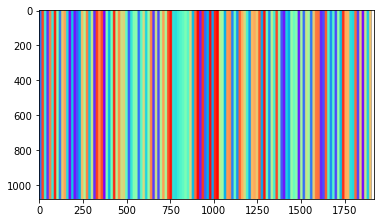

In [8]:
# Create Colors
cols = cm.rainbow(np.linspace(0, 1, len(identities))).tolist()
random.shuffle(cols)
col_map = {identities[i]: np.array(list(map(lambda x: (int)(x * 255), cols[i]))) for i in range(len(identities))}
col_map[-1] = np.ones(4) # Root is white 

# Display test colors
px_row = [[1, col_map[id]] for id in col_map]
test_px = line_from_data(px_row, res[1])
array = np.array([test_px] * res[0], dtype=np.uint8)
resized = cv2.resize(array, res)
new_image = Image.fromarray(resized)
plt.imshow(new_image)

In [9]:
def get_image_pixels(tree, rootId, pop_df, col_map, breath):
    img_pixels = []
    for i in range(0, gen_count):
        pop_dict = get_pop_dict(pop_df, i)
        id_rows = descend(tree, pop_dict, rootId)
        pixel_row = [(id_row[0], col_map[id_row[1]]) for id_row in id_rows]
        line_px = line_from_data(pixel_row, res[1] * scale_up)
        img_pixels.append(line_px)
    return img_pixels

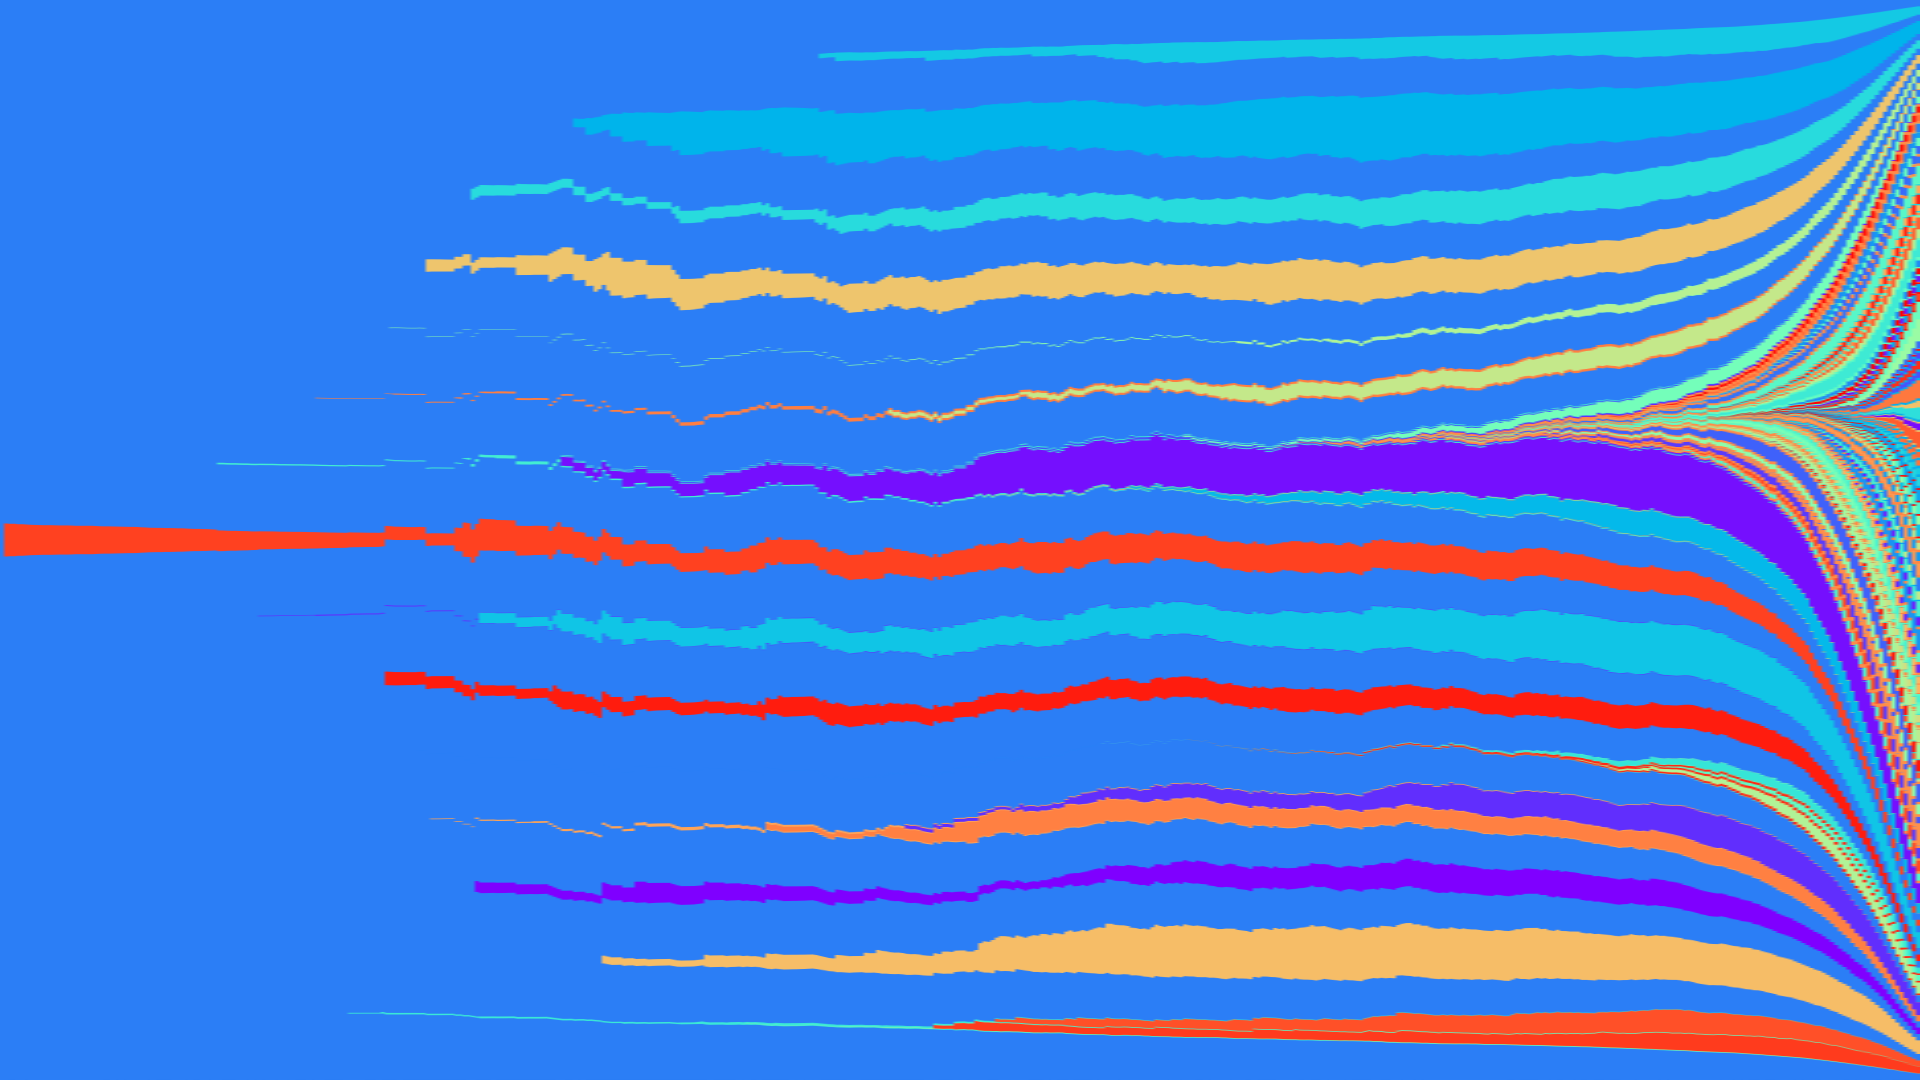

In [10]:
img_pixels = get_image_pixels(tree, root, populations_df, col_map, res[1] * scale_up)
px_array = np.array(img_pixels, dtype=np.uint8)
resized = cv2.resize(px_array, [res[1], res[0]]) # Switch coordintaes as it's before the rotation
new_image = Image.fromarray(resized).transpose(Image.ROTATE_270).transpose(Image.FLIP_LEFT_RIGHT)
new_image